# Generate Hd-EMG data using NeuroMotion package through MUniverse

This notebook demonstrates how to generate Hd-EMG data using the NeuroMotion package.

Simulating Hd-EMG data is a four step process:

1. Generate muscle activation patterns
2. Generate motor unit action potential (MUAP) shapes
3. Generate surface EMG signals
4. Add noise and simulate sensor readings

Here, we will use the `muniverse.datasets` module to generate Hd-EMG data for two scenarios:

1. Simulating synthetic data using the MUAP shapes from `BioMime`
2. Simulating Hd-EMG data from a pre-existing MUAP shape database (which has been collected from experimental recordings)

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
from muniverse.datasets import movement
import matplotlib.pyplot as plt
import numpy as np

## 1. Generate a synthetic trial



In [3]:
import json
config = json.load(open("../configs/neuromotion.json"))
myconfig = config.copy()

In [18]:
my_movement_config = {
    "EffortProfile": "Ballistic",
    "InitialEffort": 30,
    "TargetEffort": 80,
    "AngleProfile": "Constant",
    "InitialAngle": 0,
    "TargetAngle": 0,
    
    "NRepetitions": 2,
    "RestDuration": 3,
    "RampDuration": 5,
    "HoldDuration": 10,
    "SinFrequency": 0.2,
    "MovementDuration": 52
}
my_movement_dof = "Radial-Ulnar-Deviation"

myconfig['MovementConfiguration']['MovementProfileParameters'] = my_movement_config 
myconfig['MovementConfiguration']['MovementDOF'] = my_movement_dof

In [19]:
effort_profile, params = movement.generate_effort_profile(myconfig)
angle_profile, params = movement.generate_angle_profile(myconfig)
t = np.arange(0, my_movement_config['MovementDuration'], 1/myconfig['RecordingConfiguration']['SamplingFrequency'])

<string>:13: UserWarning: NRepetitions is less than 5. Setting to 5.


In [22]:
params

{'EffortProfile': 'Ballistic',
 'InitialEffort': 0,
 'TargetEffort': 80,
 'AngleProfile': 'Constant',
 'InitialAngle': 0,
 'TargetAngle': 0,
 'NRepetitions': 5,
 'RestDuration': 3,
 'RampDuration': 5,
 'HoldDuration': 0,
 'SinFrequency': 0,
 'MovementDuration': 65}

ValueError: x and y must have same first dimension, but have shapes (133120,) and (665600,)

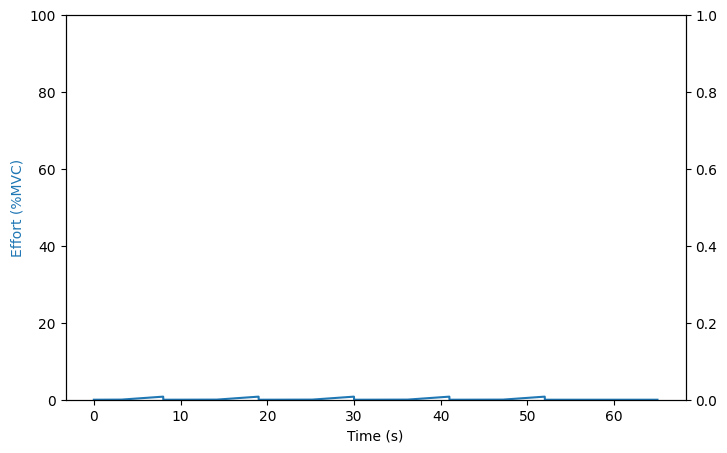

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(t, effort_profile, label="Effort (%MVC)", color="C0")
ax.set_ylim(0, 100)
ax.set_ylabel("Effort (%MVC)", color="C0")
ax.set_xlabel("Time (s)")

ax2 = ax.twinx()
ax2.plot(t, angle_profile, label="Angle", color="C1")
if my_movement_dof == "Flexion-Extension":
    ax2.set_ylim(-65, 65)
    ax2.set_ylabel("Angle (deg)", color="C1")
elif my_movement_dof == "Radial-Ulnar-Deviation":
    ax2.set_ylim(-10, 25)
    ax2.set_ylabel("Angle (deg)", color="C1")

plt.title(f"Movement profile ({my_movement_dof}) for synthetic trial")
plt.show()